In [30]:
# q8
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [33]:
data = pd.read_csv("breast_cancer.csv")


In [34]:
data.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [36]:
tree_values = [20, 50, 100, 200, 500]
accuracies = []


In [37]:
for n in tree_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"Trees: {n} --> Accuracy: {acc:.4f}")


Trees: 20 --> Accuracy: 0.7556
Trees: 50 --> Accuracy: 0.7556
Trees: 100 --> Accuracy: 0.7556
Trees: 200 --> Accuracy: 0.7778
Trees: 500 --> Accuracy: 0.7778


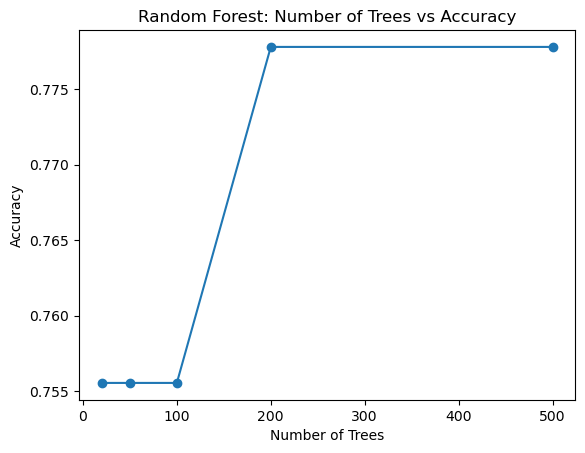

In [38]:
plt.figure()
plt.plot(tree_values, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest: Number of Trees vs Accuracy")
plt.show()

In [12]:
# q9
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [41]:
data = pd.read_csv("iris.csv")

In [42]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [44]:
k_values = [1, 3, 5, 7, 11]
accuracy_scores = {}

In [45]:
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores[k] = accuracy
    print(f"Accuracy with k={k}: {accuracy:.4f}")

Accuracy with k=1: 0.7778
Accuracy with k=3: 0.7333
Accuracy with k=5: 0.8000
Accuracy with k=7: 0.7778
Accuracy with k=11: 0.7778


In [46]:
results = pd.Series(accuracy_scores)
print("\nComparison of Accuracies:")
print(results)


Comparison of Accuracies:
1     0.777778
3     0.733333
5     0.800000
7     0.777778
11    0.777778
dtype: float64


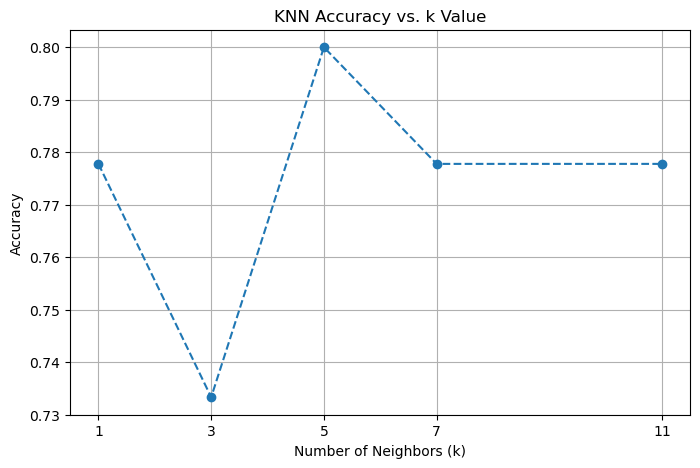

In [47]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, results, marker='o', linestyle='--')
plt.title('KNN Accuracy vs. k Value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [48]:
# q10
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [49]:
data=pd.read_csv("iris.csv")

In [50]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [52]:
kernels = ['linear', 'poly', 'rbf']
accuracies = {}



In [53]:
plt.figure(figsize=(15, 5))
for i, kernel in enumerate(kernels):
    clf = SVC(kernel=kernel, degree=3 if kernel == 'poly' else 3, gamma='scale')
    clf.fit(X_train, y_train)


    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies[kernel] = acc
    print(f"{kernel.capitalize()} Accuracy: {acc:.4f}")

Linear Accuracy: 0.7333
Poly Accuracy: 0.7556
Rbf Accuracy: 0.7333


<Figure size 1500x500 with 0 Axes>

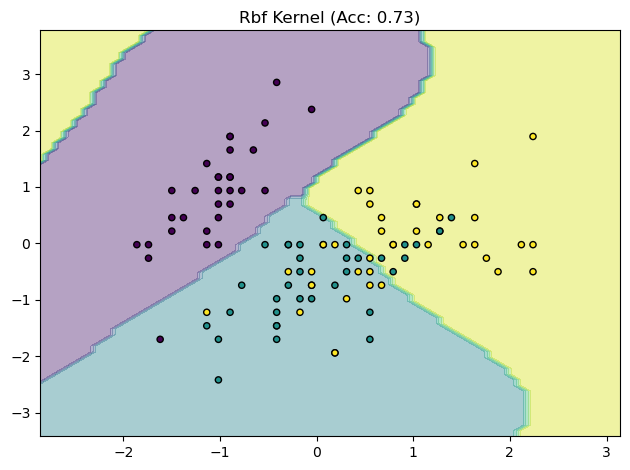

In [54]:
plt.plot(1, 3,  i+1)
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20, edgecolor='k')
plt.title(f'{kernel.capitalize()} Kernel (Acc: {acc:.2f})')

plt.tight_layout()
plt.show()

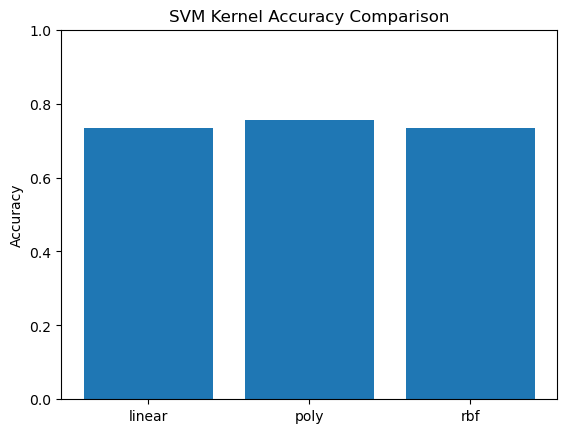

In [55]:
plt.bar(accuracies.keys(), accuracies.values())
plt.ylabel('Accuracy')
plt.title('SVM Kernel Accuracy Comparison')
plt.ylim([0, 1])
plt.show()